# Acrobot Vertical Random Baseline

## 实验目标

这个 notebook 使用自定义的竖直目标 Acrobot 环境进行随机动作统计。目标不是训练策略，而是先确认在更严格的成功定义下，纯随机力矩几乎不可能让双连杆摆动到接近完全竖直并稳定保持。后续 `PPO` 的结果将以这份基线作为参照。

## 环境定义

这里不再沿用原版 `Acrobot-v1` 的终止条件。为了把目标明确收紧到接近完全竖直，环境改成满足以下条件才算成功：

- 第一根杆接近正上方
- 第二根杆相对第一根杆接近对齐
- 两个关节角速度足够小
- 上述状态连续保持若干步

这意味着该任务不仅要求摆上去，还要求在接近竖直的位置保持短暂稳定。

## 方法说明

方法仍然是纯随机动作采样：每一步在三个离散力矩中随机选择，不使用价值函数，不做策略更新。这个基线的意义在于给出严格目标下的自然难度下限。

## 设备与并行说明

- 本实验使用 `CPU`
- 不使用 `MPS`
- 不启用并行环境

这里的重点是环境统计，不涉及策略网络训练。

In [1]:
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from vertical_acrobot_env import make_vertical_acrobot_env

In [2]:
NUM_EPISODES = 1000
MAX_STEPS = 600
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
SEED = 42
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

env = make_vertical_acrobot_env(max_episode_steps=MAX_STEPS)

## 参数选择说明

- `NUM_EPISODES = 1000`：保证随机统计足够稳定
- `MAX_STEPS = 600`：给严格竖直目标留出完整摆动时间
- `ROLLOUT_EPISODES = 3`：保留少量轨迹用于回放核对

如果随机策略在这个环境里仍能稳定成功，说明目标定义太松；如果成功率接近零，则说明任务难度设置是合理的。

In [3]:
episode_rewards = []
episode_lengths = []
successes = []
final_tip_heights = []
final_theta1_errors = []
final_theta2_errors = []

for episode in tqdm(range(NUM_EPISODES), desc='Random episodes'):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    last_info = {}

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        last_info = info
        if terminated or truncated:
            episode_lengths.append(step + 1)
            successes.append(int(info.get('is_vertical_success', False)))
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successes.append(0)

    episode_rewards.append(total_reward)
    final_tip_heights.append(float(last_info.get('tip_height', np.nan)))
    final_theta1_errors.append(float(last_info.get('theta1_error', np.nan)))
    final_theta2_errors.append(float(last_info.get('theta2_error', np.nan)))

env.close()

Random episodes:   0%|          | 0/1000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame({
    'reward': episode_rewards,
    'episode_length': episode_lengths,
    'success': successes,
    'final_tip_height': final_tip_heights,
    'final_theta1_error': final_theta1_errors,
    'final_theta2_error': final_theta2_errors,
})
summary.describe(include='all')

,reward,episode_length,success,final_tip_height,final_theta1_error,final_theta2_error
count,1000.000000,1000.0,1000.0,1000.000000,1000.000000,1000.000000
mean,-1936.993967,600.0,0.0,-1.232753,2.583451,1.145805
std,108.248088,0.0,0.0,0.670993,0.445184,0.801494
min,-2058.276146,600.0,0.0,-1.999657,0.149674,0.004988
25%,-2006.022423,600.0,0.0,-1.769859,2.355747,0.485374
50%,-1963.987592,600.0,0.0,-1.433884,2.687363,0.987747
75%,-1903.313618,600.0,0.0,-0.847199,2.914464,1.697948
max,-1049.872939,600.0,0.0,1.860062,3.141036,3.139619


In [5]:
metrics = pd.DataFrame({
    'metric': [
        'average_reward',
        'average_episode_length',
        'success_rate',
        'average_final_tip_height',
        'average_final_theta1_error',
        'average_final_theta2_error',
    ],
    'value': [
        float(np.mean(episode_rewards)),
        float(np.mean(episode_lengths)),
        float(np.mean(successes)),
        float(np.nanmean(final_tip_heights)),
        float(np.nanmean(final_theta1_errors)),
        float(np.nanmean(final_theta2_errors)),
    ],
})
metrics

,metric,value
0,average_reward,-1936.993967
1,average_episode_length,600.000000
2,success_rate,0.000000
3,average_final_tip_height,-1.232753
4,average_final_theta1_error,2.583451
5,average_final_theta2_error,1.145805


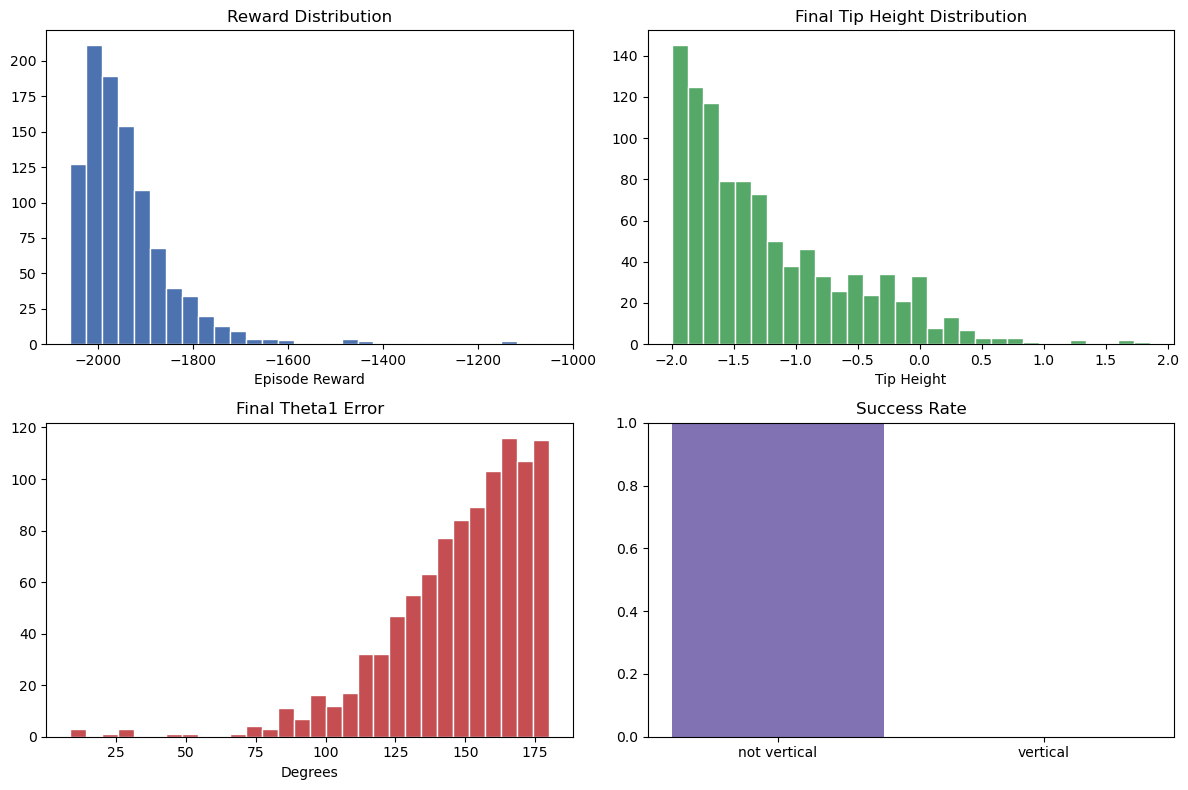

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(episode_rewards, bins=30, color='#4c72b0', edgecolor='white')
axes[0, 0].set_title('Reward Distribution')
axes[0, 0].set_xlabel('Episode Reward')

axes[0, 1].hist(final_tip_heights, bins=30, color='#55a868', edgecolor='white')
axes[0, 1].set_title('Final Tip Height Distribution')
axes[0, 1].set_xlabel('Tip Height')

axes[1, 0].hist(np.degrees(final_theta1_errors), bins=30, color='#c44e52', edgecolor='white')
axes[1, 0].set_title('Final Theta1 Error')
axes[1, 0].set_xlabel('Degrees')

axes[1, 1].bar(['not vertical', 'vertical'], [1 - np.mean(successes), np.mean(successes)], color=['#8172b3', '#64b5cd'])
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('Success Rate')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'random_baseline_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = make_vertical_acrobot_env(render_mode='rgb_array', max_episode_steps=MAX_STEPS)
    obs, info = rollout_env.reset(seed=SEED + 10000 + rollout_idx)
    frames = []
    total_reward = 0.0
    last_info = {}

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action = rollout_env.action_space.sample()
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        last_info = info
        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.extend([final_frame] * 20)
            rollout_summaries.append({
                'rollout_index': rollout_idx + 1,
                'seed': SEED + 10000 + rollout_idx,
                'total_reward': float(total_reward),
                'steps': step + 1,
                'success': int(info.get('is_vertical_success', False)),
                'tip_height': float(info.get('tip_height', np.nan)),
            })
            break

    if frames:
        imageio.mimsave(RESULTS_DIR / f'random_baseline_rollout_{rollout_idx + 1}.gif', frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,steps,success,tip_height
0,1,10042,-1910.068979,600,0,-1.428209
1,2,10043,-2038.434007,600,0,-1.895380
2,3,10044,-2030.543419,600,0,-1.893395


In [8]:
summary.to_csv(RESULTS_DIR / 'random_baseline_episode_summary.csv', index=False)
metrics.to_csv(RESULTS_DIR / 'random_baseline_metrics.csv', index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / 'random_baseline_rollout_summary.csv', index=False)
print(metrics.to_string(index=False))

                    metric        value
            average_reward -1936.993967
    average_episode_length   600.000000
              success_rate     0.000000
  average_final_tip_height    -1.232753
average_final_theta1_error     2.583451
average_final_theta2_error     1.145805


## 结果解读

如果随机基线的成功率接近零、终点高度明显不足、末端角误差较大，就说明严格竖直目标确实需要形成稳定的摆动与减速策略，不能靠随机试错碰出来。